In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Example dataset
data = {
    'age': [3, 25, 29, 31, 120, 27, 26, np.nan],
    'income': [40000, 50000, 60000, 65000, 1000000, 52000, np.nan, 48000]
}
# Create DataFrame
df = pd.DataFrame(data)

In [3]:
# Display DataFrame and shape
print(df.shape)
df.head(8)

(8, 2)


,age,income
0,3.0,40000.0
1,25.0,50000.0
2,29.0,60000.0
3,31.0,65000.0
4,120.0,1000000.0
5,27.0,52000.0
6,26.0,NaN
7,NaN,48000.0


In [4]:
df.isnull().sum()

age       1
income    1
dtype: int64

In [5]:
df.age.mean()

37.285714285714285

In [6]:
df.income.median()

52000.0

In [7]:
df.age.mean(),df.income.median()

(37.285714285714285, 52000.0)

### Imputing age with mean and income with median value

In [8]:
df['age'] = df['age'].fillna(df['age'].mean())
df['income'] = df['income'].fillna(df['income'].median())

In [9]:
df.head(8)

,age,income
0,3.000000,40000.0
1,25.000000,50000.0
2,29.000000,60000.0
3,31.000000,65000.0
4,120.000000,1000000.0
5,27.000000,52000.0
6,26.000000,52000.0
7,37.285714,48000.0


### Checking outliers in df

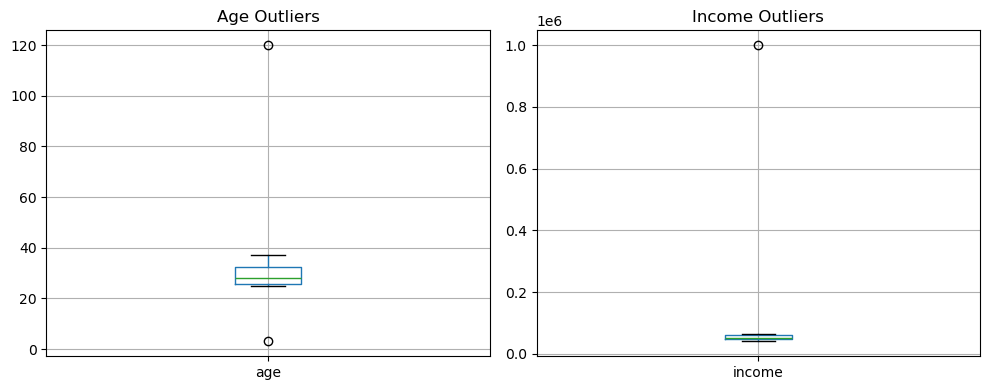

In [10]:


# data = {
#     'age': [23, 25, 29, 31, 120, 27, 26, np.nan],
#     'income': [40000, 50000, 60000, 65000, 1000000, 52000, np.nan, 48000]
# }

# df = pd.DataFrame(data)

# Boxplots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df.boxplot(column='age')
plt.title('Age Outliers')

plt.subplot(1, 2, 2)
df.boxplot(column='income')
plt.title('Income Outliers')

plt.tight_layout()
plt.show()

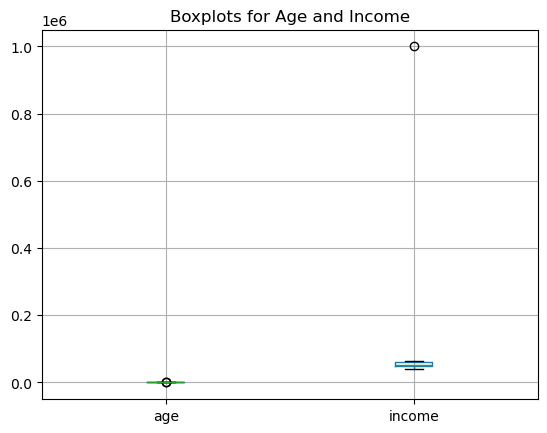

In [11]:
import matplotlib.pyplot as plt

df[['age', 'income']].boxplot()
plt.title('Boxplots for Age and Income')
plt.show()

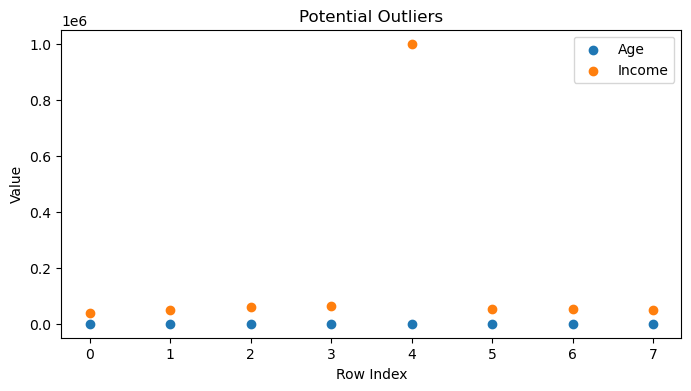

In [12]:
plt.figure(figsize=(8, 4))

plt.scatter(df.index, df['age'], label='Age')
plt.scatter(df.index, df['income'], label='Income')

plt.legend()
plt.xlabel('Row Index')
plt.ylabel('Value')
plt.title('Potential Outliers')
plt.show()

In [13]:
# Age outliers
Q1_age = df['age'].quantile(0.25) # First quartile
Q3_age = df['age'].quantile(0.75) # Third quartile

In [14]:
Q1_age,Q3_age

(25.75, 32.57142857142857)

In [15]:
IQR_age = Q3_age - Q1_age # Inter-Quartile Range
IQR_age

6.821428571428569

In [16]:
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

lower_age,upper_age

(15.517857142857146, 42.80357142857142)

In [17]:
age_outliers = df[(df['age'] < lower_age) | (df['age'] > upper_age)]

print("Age Outliers:")
print(age_outliers)

Age Outliers:
     age     income
0    3.0    40000.0
4  120.0  1000000.0


In [18]:
# Income outliers
Q1_income = df['income'].quantile(0.25) # First quartile
Q3_income = df['income'].quantile(0.75)

Q1_income,Q3_income

(49500.0, 61250.0)

In [19]:
IQR_income = Q3_income - Q1_income
IQR_income

11750.0

In [20]:
lower_income = Q1_income - 1.5 * IQR_income
upper_income = Q3_income + 1.5 * IQR_income

lower_income,upper_income

(31875.0, 78875.0)

In [21]:
income_outliers = df[(df['income'] < lower_income) | (df['income'] > upper_income)]

print("\nIncome Outliers:")
print(income_outliers)


Income Outliers:
     age     income
4  120.0  1000000.0


In [22]:
df.head(8)

,age,income
0,3.000000,40000.0
1,25.000000,50000.0
2,29.000000,60000.0
3,31.000000,65000.0
4,120.000000,1000000.0
5,27.000000,52000.0
6,26.000000,52000.0
7,37.285714,48000.0


In [23]:
for col in ['age', 'income']:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

print(df.shape)
df.head(8)

(8, 2)


,age,income
0,15.517857,40000.0
1,25.000000,50000.0
2,29.000000,60000.0
3,31.000000,65000.0
4,42.803571,78875.0
5,27.000000,52000.0
6,26.000000,52000.0
7,37.285714,48000.0


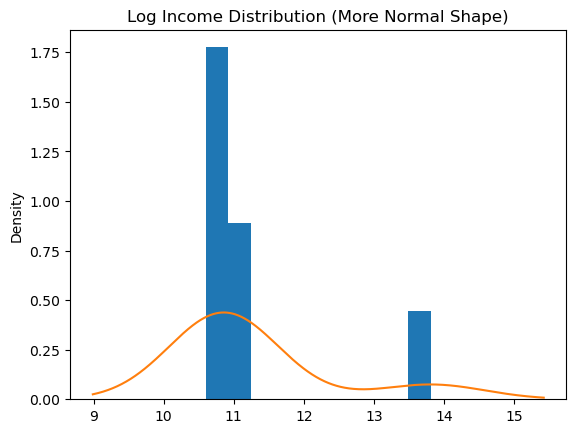

In [28]:
log_income = np.log(df['income']) 

log_income.plot(kind='hist', density=True) 
log_income.plot(kind='kde') 
plt.title("Log Income Distribution (More Normal Shape)") 
plt.show()


In [29]:
log_income

0    10.596635
1    10.819778
2    11.002100
3    11.082143
4    13.815511
5    10.858999
6          NaN
7    10.778956
Name: income, dtype: float64